# PHASE 1: A/B Testing - Experimentation Platform Project

## Project Introduction

Welcome to the **Experimentation Platform**, a project focused on A/B testing. In this first phase, you will learn fundamental concepts of digital experimentation in a hands-on way.

### Goals of this phase:
1. Understand what an A/B test is
2. Generate realistic synthetic data
3. Implement a basic experiment analysis
4. Visualize results

**Note**: This is an educational project. The concepts here apply directly to real-world cases in e-commerce, mobile applications, and digital marketing.

## STEP 1: Import Required Libraries

In Data Science, libraries are like tools in a toolbox. Each has a specific purpose:

| Library | Purpose |
|----------|----------|
| **pandas** | Data manipulation and analysis in tables (DataFrames) |
| **numpy** | Numerical operations and array handling |
| **matplotlib** | Creating charts and visualizations |
| **random** | Random number generation (built into Python) |

These are the tools we need to process and analyze the experiment.

In [1]:
# Import fundamental libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Set random seed for reproducibility
# This ensures you get the same results every time you run the notebook
np.random.seed(42)
random.seed(42)

print(" Libraries imported successfully")

 Libraries imported successfully


## STEP 2: Create Synthetic Dataset

### What is an A/B Test?

An **A/B test** is an experiment where:
- We divide users into **two groups** randomly
- **Control Group (A)**: They see the original version
- **Treatment Group (B)**: They see the new/modified version
- We measure a metric (e.g. conversion) in both groups
- We compare results to decide whether the change is beneficial

**Real example**: An online store wants to know whether changing the "Buy" button color from blue to orange increases conversions.

### Why do we use the binomial distribution?

Conversion is a **binary** event (it happens or it doesn't):
- User buys (1) or doesn't buy (0)
- User subscribes (1) or doesn't subscribe (0)

The binomial distribution models exactly this: the number of successes in n independent trials.

### Dataset structure:

We will create a dataset with **10,000 users** and the following columns:
- **user_id**: Unique user identifier
- **treatment**: 0 = Control (original version), 1 = Treatment (new version)
- **conversion**: 1 = Converted, 0 = Did not convert

In [2]:
# Define experiment parameters
n_users = 10000
prob_conversion_control = 0.10 # Control group has 10% conversion rate
prob_conversion_treatment = 0.12 # Treatment group has 12% conversion rate

# Create the synthetic dataset
data = {
'user_id': range(1, n_users + 1),

# Random assignment: 50% control, 50% treatment using binomial distribution
'treatment': np.random.binomial(n=1, p=0.5, size=n_users),

# Placeholder for conversion (we will fill it in later)
'conversion': None
}

# Create DataFrame
df = pd.DataFrame(data)

# Generate conversions based on group (control or treatment)
# If treatment=0 (control): use prob_conversion_control
# If treatment=1 (treatment): use prob_conversion_treatment
df['conversion'] = df['treatment'].apply(
lambda x: np.random.binomial(n=1, p=prob_conversion_treatment if x == 1 else prob_conversion_control)
)

print("Synthetic dataset created successfully")
print(f"Total users: {len(df)}")
print(f"\nFirst 5 rows of the dataset:")
print(df.head())
print(f"\nDataset info:")
print(df.info())

Synthetic dataset created successfully
Total users: 10000

First 5 rows of the dataset:
   user_id  treatment  conversion
0        1          0           0
1        2          1           0
2        3          1           0
3        4          1           0
4        5          0           0

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     10000 non-null  int64
 1   treatment   10000 non-null  int32
 2   conversion  10000 non-null  int64
dtypes: int32(1), int64(2)
memory usage: 195.4 KB
None


### Initial dataset analysis

Let's verify that the distribution is correct and that we have approximately the same number of users in each group.

In [3]:
# Verify the user distribution by group
print("User distribution by group:")
print(df['treatment'].value_counts().sort_index())
print()

# Conversion distribution
print("Conversion distribution:")
print(df['conversion'].value_counts())
print()

# Conversions by group
print("Conversions by group:")
print(pd.crosstab(df['treatment'], df['conversion'], margins=True))

User distribution by group:
treatment
0    5076
1    4924
Name: count, dtype: int64

Conversion distribution:
conversion
0    8859
1    1141
Name: count, dtype: int64

Conversions by group:
conversion     0     1    All
treatment                    
0           4557   519   5076
1           4302   622   4924
All         8859  1141  10000


## STEP 3: Create run_ab_test() Function

### Key concepts:

**Control vs Treatment:**
- **Control (A)**: Baseline group (no changes). This is our "reference point"
- **Treatment (B)**: Experimental group (with the change). This is what we want to test

**Conversion Rate:**
- It is the percentage of users who converted
- `Conversion Rate = (Users who converted / Total users) × 100%`

**Uplift:**
- It is the **relative change** in the metric when comparing treatment vs control
- `Uplift = ((Treatment - Control) / Control) × 100%`
- If Uplift is positive: treatment is better
- If Uplift is negative: control is better

**Why do we use the mean?**
- The mean (average) is the simplest indicator of the conversion rate
- For binary data (0 and 1), the mean equals exactly the conversion rate
- It is interpretable: a mean of 0.12 = 12% conversion

In [4]:
def run_ab_test(dataframe):
    """
    Function to run a basic A/B test analysis.

    Parameters:
    -----------
    dataframe : pd.DataFrame
    DataFrame with columns 'treatment' and 'conversion'

    Returns:
    --------
    dict : Dictionary with experiment results
    """

    # Separate data by group
    control = dataframe[dataframe['treatment'] == 0]['conversion']
    treatment = dataframe[dataframe['treatment'] == 1]['conversion']

    # Calculate metrics
    control_mean = control.mean() # Control conversion rate
    treatment_mean = treatment.mean() # Treatment conversion rate

    # Calculate uplift
    uplift = ((treatment_mean - control_mean) / control_mean) * 100

    # Create results dictionary
    results = {
    'control_size': len(control),
    'treatment_size': len(treatment),
    'control_conversions': control.sum(),
    'treatment_conversions': treatment.sum(),
    'control_conversion_rate': control_mean,
    'treatment_conversion_rate': treatment_mean,
    'uplift_percentage': uplift
    }

    return results

print(" Function run_ab_test() defined successfully")

 Function run_ab_test() defined successfully


## STEP 4: Run the Experiment

Now we will run the function with our dataset and see the experiment results.

In [5]:
# Run the A/B test
results = run_ab_test(df)

# Display results clearly
print("" + "="*60)
print("A/B TEST RESULTS")
print("="*60)
print()
print(f"CONTROL GROUP (Original Version):")
print(f" Group size: {results['control_size']:,} users")
print(f" Conversions: {results['control_conversions']:,} users")
print(f" Conversion rate: {results['control_conversion_rate']:.2%}")
print()
print(f"TREATMENT GROUP (New Version):")
print(f" Group size: {results['treatment_size']:,} users")
print(f" Conversions: {results['treatment_conversions']:,} users")
print(f" Conversion rate: {results['treatment_conversion_rate']:.2%}")
print()
print(f"COMPARATIVE ANALYSIS:")
print(f" Uplift: {results['uplift_percentage']:+.2f}%")
print()
if results['uplift_percentage'] > 0:
    print(f" The treatment is BETTER than the control")
    print(f" The new version increases conversion by {results['uplift_percentage']:.2f}%")
else:
    print(f" The control is BETTER than the treatment")
    print(f" The new version decreases conversion by {abs(results['uplift_percentage']):.2f}%")
print("="*60)

A/B TEST RESULTS

CONTROL GROUP (Original Version):
 Group size: 5,076 users
 Conversions: 519 users
 Conversion rate: 10.22%

TREATMENT GROUP (New Version):
 Group size: 4,924 users
 Conversions: 622 users
 Conversion rate: 12.63%

COMPARATIVE ANALYSIS:
 Uplift: +23.55%

 The treatment is BETTER than the control
 The new version increases conversion by 23.55%


### Results Interpretation

**What does each metric mean?**

1. **Conversion Rate**:
- The percentage of users who performed the desired action
- Control: 10% = out of every 100 users, 10 purchased
- Treatment: 12% = out of every 100 users, 12 purchased

2. **Uplift**:
- Shows the relative change (in percentage) between the two groups
- An uplift of +2% means the treatment has 2% more conversion than the control
- In absolute terms: 12% - 10% = 2 percentage points
- En términos relativos: (2% / 10%) × 100 = +20% de mejora

**Important note**: In this phase 1, we do NOT perform statistical Significance tests. En fases posteriores (t-test, p-values), verificaremos si estos resultados son statisticalmente significativos o solo fruto del azar.

## STEP 5: Results Visualization

Visualizations are crucial in Data Science. A well-made chart communicates complex information immediately.

### What Are We Visualizing?
A comparative bar chart showing the conversion rate of both groups side by side.

### How to Interpret the Chart?
- **X-Axis**: The two groups (Control and Treatment)
- **Y-Axis**: Conversion rate (0% to 15%)
- **Altura de las barras**: Misma altura = rendimiento similar. Altura diferente = un grupo convierte más.
- **Color**: Rojo para control (original), Green for treatment (new)

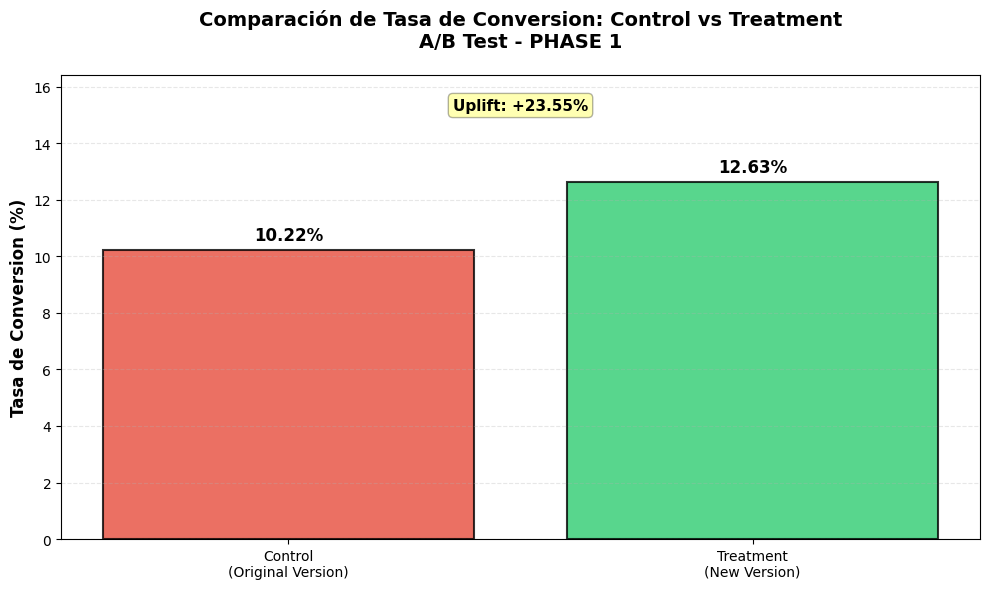

Comparison chart created successfully


In [6]:
# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Data for the chart
groups = ['Control\n(Original Version)', 'Treatment\n(New Version)']
conversion_rates = [
results['control_conversion_rate'] * 100, # Convert to percentage
results['treatment_conversion_rate'] * 100
]
colors = ['#e74c3c', '#2ecc71'] # Red for control, green for treatment

# Create bars
bars = ax.bar(groups, conversion_rates, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add values above the bars
for i, (bar, rate) in enumerate(zip(bars, conversion_rates)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{rate:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Configurar el chart
ax.set_ylabel('Tasa de Conversion (%)', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Tasa de Conversion: Control vs Treatment\nA/B Test - PHASE 1', 
fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, max(conversion_rates) * 1.3) # Dejar espacio para los valores
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Añadir información del uplift
uplift_text = f"Uplift: {results['uplift_percentage']:+.2f}%"
ax.text(0.5, 0.95, uplift_text, transform=ax.transAxes,
ha='center', va='top', fontsize=11, fontweight='bold',
bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

print("Comparison chart created successfully")

## PHASE 1 Summary

### What have we accomplished?

1. **Conceptualization**: Understanding what an A/B test is and its components
2. **Data generation**: We created a realistic synthetic dataset of 10,000 users
3. **Analysis**: We implemented a function to calculate key metrics (conversion rate, uplift)
4. **Execution**: We ran the experiment and obtained results
5. **Visualization**: We presented results graphically

### Concepts learned:
- A/B Testing: dividing users into groups and comparing results
- Binomial Distribution: model for events with two possible outcomes
- Conversion Rate: Percentage de users que completaron una acción
- Uplift: Relative change in the metric between groups
- Comparative analysis: how to interpret results de experimentos

### Próximas Fases (no implemented here):
- **PHASE 2**: Statistical analysis (t-test, p-values, confidence intervals)
- **PHASE 3**: Determinar required sample size
- **PHASE 4**: Multivariate A/B testing (3+ variants)
- **PHASE 5**: Implement interactive platform en Streamlit

---

# PHASE 2: Statistical Validation with T-Test

## STEP 6: Why Is Uplift NOT Enough?

### The Problem

So far, we have seen that:
- **Control**: 10% conversion
- **Treatment**: 12% conversion
- **Uplift**: +20%

**Critical question**: Is this difference **real** or just **luck/random noise**?

### What does "significant result" mean?

In statistics, a result is **significant** when:
- The observed difference is **unlikely** to be due to chance
- We can be sure (with a certain level of confidence) that a real effect exists

### Noise vs Real Effect

Imagine you launch a coin 100 times esperando 50 caras:
- **Si obtienes 51 heads**: It is probably noise/chance
- **Si obtienes 70 caras**: Algo sospechoso, la moneda podría estar sesgada

En A/B testing es igual:
- Pequeñas diferences (1-2%) → Probably noise
- Large differences (20-30%) Probablemente efecto real

**Pero necesitamos datos para comprobarlo**, no intuición. Para eso usamos **pruebas statisticals**.

### El T-Test: Nuestro Detective

El **t-test** es una Statistical test que responde:

> "¿Es the difference between control and treatment statistically significant or just due to chance?"

No es magia, es matemática sólida basada en probabilidades.

## STEP 7: Import Statistical Library (scipy.stats)

**SciPy** is the Python library for **advanced scientific computing**.

Within SciPy, the **`stats`** module contains professional statistical functions.

### Why scipy.stats?

| Aspect | Detail |
|--------|--------|
| **Function** | Provides standard statistical tests (t-test, chi-square, etc.) |
| **Reliability** | Used by scientists, researchers, and Fortune 500 companies |
| **Precisión** | Implementación robusta de algoritmos estadísticos probados |
| **Flexibilidad** | Soporta muchos tipos de different tests |

In this phase, we will use:
- `scipy.stats.ttest_ind()` Prueba t para muestras independientes

La función calcula automáticamente el **p-value**, que es lo que necesitamos para tomar decisiones.

In [7]:
# Import scipy.stats for statistical tests
from scipy import stats

print("scipy.stats imported successfully")
print(f"SciPy version: {stats.__version__ if hasattr(stats, '__version__') else 'unknown'}")

scipy.stats imported successfully
SciPy version: unknown


## STEP 8: Implement the T-Test Function

### What does the t-test do?

The **t-test** is a statistical test that measures:

1. **What is the difference between the two groups?**
- Control average
- Treatment average
- Absolute difference

2. **How much variability is there in the data?**
- If there is a lot of variability, the difference could be noise
- If there is little variability, the difference is more "real"

3. **How likely is this difference due to chance?**
- This is captured in a number: the **p-value**

### ¿Qué es el p-value?

El **p-value** (p-valor) es:
- Un número entre **0 y 1**
- Representa la probabilidad de observar estos datos si **NO hubiera difereal difference** between control and treatment
- Es la respuesta a: "¿Qué tan raro es lo que observamos?"

**Interpretation intuitiva:**
- `p-value = 0.01` Apenas 1% de probabilidad de verlo por azar (muy significativo)
- `p-value = 0.50` 50% de probabilidad de observe it by chance (probably noise)

### Function Code

We will create ana función que:
1. Receives two arrays (control and treatment)
2. Runs the t-test
3. Retorna el p-value y el estadístico t

In [8]:
def perform_t_test(control_data, treatment_data):
    """
    Runs an independent two-sample t-test.

    Parameters:
    -----------
    control_data : array-like
    Control group data (conversion values: 0 or 1)
    treatment_data : array-like
    Treatment group data (conversion values: 0 or 1)

    Returns:
    --------
    dict : Dictionary with:
    - 't_statistic': The t-statistic value
    - 'p_value': The p-value of the test
    - 'significant': Boolean, True if p < 0.05
    """

    # Ejecutar la prueba t-test
    # ttest_ind = test t para muestras independientes
    # Por defecto asume varianzas iguales (equal_var=True)
    t_stat, p_value = stats.ttest_ind(control_data, treatment_data)

    # Determine Significance (umbral estándar: α = 0.05)
    is_significant = p_value < 0.05

    results = {
    't_statistic': t_stat,
    'p_value': p_value,
    'significant': is_significant
    }

    return results

print(" Function perform_t_test() defined successfully")


 Function perform_t_test() defined successfully


## STEP 9: Apply the T-Test to Our Data

Now we will run the t-test with the experiment data to obtain the p-value.

In [9]:
# Separate control and treatment data
control_conversions = df[df['treatment'] == 0]['conversion'].values
treatment_conversions = df[df['treatment'] == 1]['conversion'].values

print(f"Data for t-test:")
print(f" Control: {len(control_conversions)} users")
print(f" Treatment: {len(treatment_conversions)} users")
print()

# Run the t-test
t_test_results = perform_t_test(control_conversions, treatment_conversions)

print(f"Resultados del T-Test:")
print(f" Estadístico t: {t_test_results['t_statistic']:.4f}")
print(f" P-value: {t_test_results['p_value']:.6f}")
print(f" Significant? {t_test_results['significant']}")
print()

# Mostrar p-value en formato Percentage para mejor intuición
probability_random = t_test_results['p_value'] * 100
print(f"Interpretation:")
print(f" Si NO hubiera direal difference between control and treatment,")
print(f" la probabilidad de observar estos datos sería: {probability_random:.4f}%")

Data for t-test:
 Control: 5076 users
 Treatment: 4924 users

Resultados del T-Test:
 Estadístico t: -3.7880
 P-value: 0.000153
 Significant? True

Interpretation:
 Si NO hubiera direal difference between control and treatment,
 la probabilidad de observar estos datos sería: 0.0153%


## STEP 10: Results Interpretation

### The Golden Rule: Significance Level α = 0.05

In data science and statistical inference, there is a **standard threshold**:

**If p-value < 0.05 → Result is SIGNIFICANT**
- The difference is statistically significant
- We can reject the hypothesis that "there is no difference"
- With 95% confidence, we say that el efecto es real

**Si p-value ≥ 0.05 Resultado NO CONCLUYENTE **
- No hay evidencia suficiente de una real difference
- It could be noise or random variation
- We would need más datos o un efecto más fuerte

### Tabla de Decisiones

| p-value | Interpretation | Decision |
|---------|---|---|
| < 0.01 | Muy significativo | Lanza la campaña con confianza |
| 0.01 - 0.05 | Significativo | Lanza con cautela, monitorea |
| > 0.05 | No significativo | Necesitas más datos o un cambio mayor |

### Errores Tipo I y Tipo II (Conceptos Básicos)

#### Type I Error (Falso Positivo)
- **¿Qué es?** Decir que hay efecto cuando realmente NO lo hay
- **¿Cuándo sucede?** Cuando α = 0.05 (5% de chance de error)
- **Riesgo:** Lanzar una feature que no funciona, desperdiciando dinero

#### Type I ErrorI (Falso Negativo)
- **¿Qué es?** Decir que NO hay efecto cuando realmente SÍ lo hay
- **¿Cuándo sucede?** Con muestras muy pequeñas o efectos débiles
- **Riesgo:** No lanzar una feature que funcionaría, perdiendo oportunidad

**Nota**: No podemos eliminar ambos errores simultáneamente. El bbalance is achieved with a good **sample size** (topic of PHASE 3).

### Cómo Comunicar Resultados

- "Resultado significativo (p = 0.02)" Comunicar a stakeholders
- "Resultado no significativo, pero positivo" NO es válido, necesitas p < 0.05
- "Necesitamos 50,000 users más para detectar este efecto" Buena comunicación

## STEP 11: Complete Results Report

We will combine all metrics (conversion rate, uplift, p-value) into a clear and professional report.

In [10]:
# Create combined report
print("=" * 80)
print("COMPLETE REPORT: A/B TEST WITH STATISTICAL VALIDATION")
print("=" * 80)
print()

# SECTION 1: Descriptive Statistics
print("1. DESCRIPTIVE STATISTICS")
print("-" * 80)
print()
print(f"CONTROL GROUP (Original Version):")
print(f" Group size: {results['control_size']:,} users")
print(f" Conversions: {results['control_conversions']:,} users")
print(f" Conversion rate: {results['control_conversion_rate']:.4f} ({results['control_conversion_rate']*100:.2f}%)")
print()

print(f"TREATMENT GROUP (New Version):")
print(f" Group size: {results['treatment_size']:,} users")
print(f" Conversions: {results['treatment_conversions']:,} users")
print(f" Conversion rate: {results['treatment_conversion_rate']:.4f} ({results['treatment_conversion_rate']*100:.2f}%)")
print()

# SECTION 2: Comparative Analysis
print("2. COMPARATIVE ANALYSIS")
print("-" * 80)
print()
diff_absolute = results['treatment_conversion_rate'] - results['control_conversion_rate']
print(f"Diferencia Absoluta: {diff_absolute:.4f} ({diff_absolute*100:.2f} puntos porcentuales)")
print(f"Uplift (Relative change): {results['uplift_percentage']:+.2f}%")
print()

# SECCIÓN 3: Statistical Results
print("3. STATISTICAL VALIDATION (T-TEST)")
print("-" * 80)
print()
print(f"Estadístico t: {t_test_results['t_statistic']:.4f}")
print(f"P-value: {t_test_results['p_value']:.6f}")
print()

# SECTION 4: Conclusion
print("4. CONCLUSION")
print("-" * 80)
print()

if t_test_results['significant']:
    print(" RESULTADO: ESTADÍSTICAMENTE SIGNIFICANT")
    print()
    print(f"Con un p-value de {t_test_results['p_value']:.6f} (< 0.05),")
    print("podemos concluir con 95% de confianza que:")
    print()
    print(f"The TREATMENT version has a better conversion rate")
    print(f"que la CONTROL version.")
    print()
    print(f"Recomendación: LANZAR la nueva versión ")
else:
    print(" RESULTADO: NO ESTADÍSTICAMENTE SIGNIFICANT")
    print()
    print(f"Con un p-value de {t_test_results['p_value']:.6f} (≥ 0.05),")
    print("NO hay evidencia suficiente de una real difference.")
    print()
    print(f"La diferencia observada ({results['uplift_percentage']:+.2f}%) podría")
    print("ser resultado del azar o variación natural.")
    print()
    print(f"Recomendación: NECESITAS MÁS DATOS o un cambio más fuerte ")

print()
print("=" * 80)

COMPLETE REPORT: A/B TEST WITH STATISTICAL VALIDATION

1. DESCRIPTIVE STATISTICS
--------------------------------------------------------------------------------

CONTROL GROUP (Original Version):
 Group size: 5,076 users
 Conversions: 519 users
 Conversion rate: 0.1022 (10.22%)

TREATMENT GROUP (New Version):
 Group size: 4,924 users
 Conversions: 622 users
 Conversion rate: 0.1263 (12.63%)

2. COMPARATIVE ANALYSIS
--------------------------------------------------------------------------------

Diferencia Absoluta: 0.0241 (2.41 puntos porcentuales)
Uplift (Relative change): +23.55%

3. STATISTICAL VALIDATION (T-TEST)
--------------------------------------------------------------------------------

Estadístico t: -3.7880
P-value: 0.000153

4. CONCLUSION
--------------------------------------------------------------------------------

 RESULTADO: ESTADÍSTICAMENTE SIGNIFICANT

Con un p-value de 0.000153 (< 0.05),
podemos concluir con 95% de confianza que:

The TREATMENT version has a be

## STEP 12: Enhanced Visualization with Confidence Intervals

### Why add confidence intervals?

So far, we showed a point estimate (e.g. 10% conversion).

**Problem**: A single number does NOT tell us how confident we are in that value.

**Solution**: Show a **range** (interval) within which the true value lies.

### 95% Confidence Interval

Es un rango que, si repitiéramos el experimento 100 veces, el 95 de esas veces contendría el verdadero valor.

Ejemplo:
- Conversion observada: 10%
- Intervalo de confianza 95%: [9.2%, 10.8%]
- Interpretation: "Estamos 95% seguros que la verdadera tasa está entre 9.2% y 10.8%"

### Visualización

We will create an chart que muestre:
1. Bars with the conversion rate
2. Vertical lines representing the confidence interval
3. Indicador visual si es significativo o no

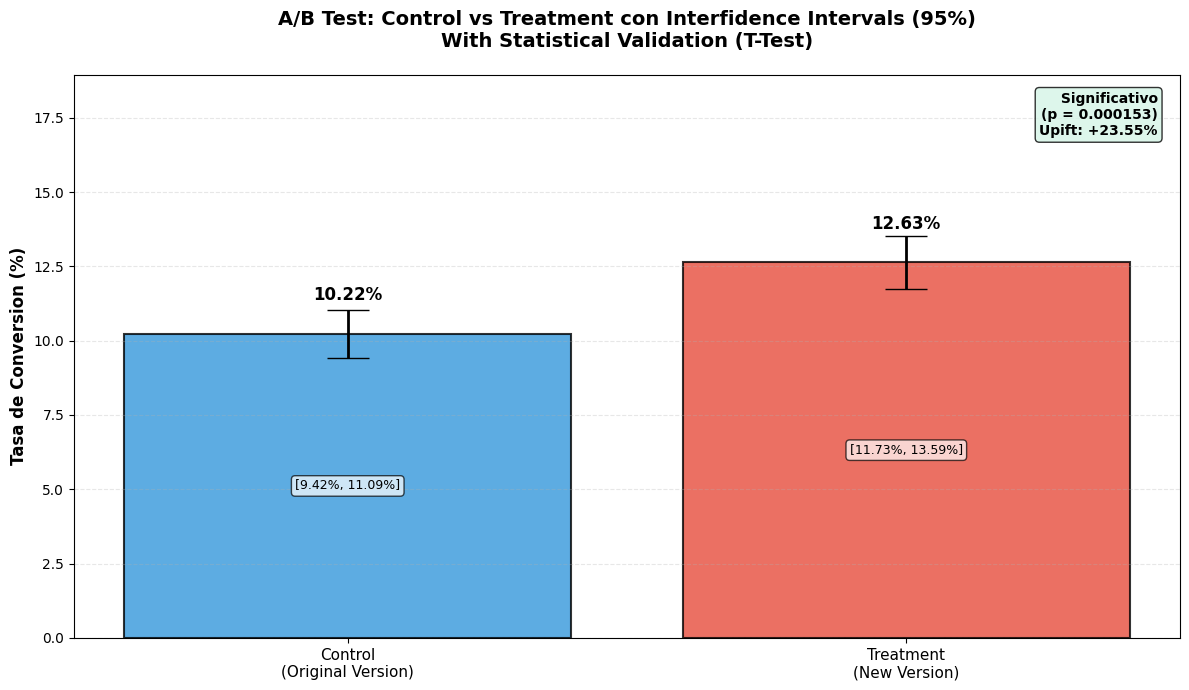

Enhanced chart created successfully

Intervalo de Confianza 95%:
 Control: [9.42%, 11.09%]
 Treatment: [11.73%, 13.59%]


In [11]:
# Calculate 95% confidence intervals using the binomial distribution
from scipy.stats import binom

# For binomial proportion, we use the Wilson score method
# which is more robust for proportions close to 0 or 1

def calculate_ci_95(successes, n):
    """
    Calculates the 95% confidence interval for a proportion using Wilson score.
    """
    p = successes / n
    z = 1.96 # critical value for 95% confidence

    denom = 1 + z**2 / n
    p_adj = (p + z**2 / (2*n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom

    ci_lower = max(0, p_adj - margin)
    ci_upper = min(1, p_adj + margin)

    return ci_lower, ci_upper

# Calcular intervalos
control_ci = calculate_ci_95(
results['control_conversions'],
results['control_size']
)
treatment_ci = calculate_ci_95(
results['treatment_conversions'],
results['treatment_size']
)

# Create visualization mejorada
fig, ax = plt.subplots(figsize=(12, 7))

# Datos
groups = ['Control\n(Original Version)', 'Treatment\n(New Version)']
means = [
results['control_conversion_rate'] * 100,
results['treatment_conversion_rate'] * 100
]
ci_errors = [
[(results['control_conversion_rate'] * 100 - control_ci[0] * 100),
(control_ci[1] * 100 - results['control_conversion_rate'] * 100)],
[(results['treatment_conversion_rate'] * 100 - treatment_ci[0] * 100),
(treatment_ci[1] * 100 - results['treatment_conversion_rate'] * 100)]
]

# Colores: Verde si significativo, Naranja si no
colors = ['#3498db', '#e74c3c'] if t_test_results['significant'] else ['#95a5a6', '#95a5a6']

# Create bars con error bars (confidence intervals)
x_pos = np.arange(len(groups))
bars = ax.bar(x_pos, means, yerr=[ci_errors[i][0] for i in range(2)], 
color=colors, alpha=0.8, capsize=15, error_kw={'linewidth': 2},
edgecolor='black', linewidth=1.5)

# Add values above the bars
for i, (bar, mean) in enumerate(zip(bars, means)):
    height = bar.get_height()
    # Valor central
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{mean:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
    # Intervalo de confianza
    ci_text = f"[{control_ci[0]*100 if i==0 else treatment_ci[0]*100:.2f}%, {control_ci[1]*100 if i==0 else treatment_ci[1]*100:.2f}%]"
    ax.text(bar.get_x() + bar.get_width()/2., height/2,
            ci_text,
            ha='center', va='center', fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Configurar chart
ax.set_ylabel('Tasa de Conversion (%)', fontsize=12, fontweight='bold')
ax.set_title('A/B Test: Control vs Treatment con Interfidence Intervals (95%)\nWith Statistical Validation (T-Test)', 
fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(groups, fontsize=11)
ax.set_ylim(0, max(means) * 1.5)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Añadir información de Significance
if t_test_results['significant']:
    Significance_text = f" Significativo\n(p = {t_test_results['p_value']:.6f})\nUpift: {results['uplift_percentage']:+.2f}%"
    box_color = '#d5f4e6'
else:
    Significance_text = f" No Significativo\n(p = {t_test_results['p_value']:.6f})\nUpift: {results['uplift_percentage']:+.2f}%"
    box_color = '#fadbd8'

ax.text(0.98, 0.97, Significance_text, transform=ax.transAxes,
ha='right', va='top', fontsize=10, fontweight='bold',
bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.8))

plt.tight_layout()
plt.show()

print("Enhanced chart created successfully")
print(f"\nIntervalo de Confianza 95%:")
print(f" Control: [{control_ci[0]*100:.2f}%, {control_ci[1]*100:.2f}%]")
print(f" Treatment: [{treatment_ci[0]*100:.2f}%, {treatment_ci[1]*100:.2f}%]")

---

## Summary of PHASE 1 + PHASE 2

### What have we accomplished?

#### PHASE 1: A/B Testing Fundamentals
1. **Conceptualization**: Understand what an A/B test is
2. **Data generation**: Synthetic dataset of 10,000 users
3. **Basic analysis**: Calculate conversion rate and uplift
4. **Visualization**: Comparative charts

#### PHASE 2: Statistical Validation (NEW)
5. **T-Test**: Implement the validation function
6. **P-Value Calculation**: Determine statistical Significance
7. **Interpretation**: Understand Type I and II Error
8. **Confidence Intervals**: Show confidence ranges
9. **Reporte Profesional**: Conclusiones claras y accionables

### Concepts Learned

**PHASE 1:**
- A/B Testing: dividing users into groups and comparing results
- Binomial Distribution: modelo para Binary events
- Conversion Rate: Percentage de conversiones
- Uplift: Relative change en la métrica

**PHASE 2 (NUEVO):**
- T-Test: Statistical test para comparar dos grupos
- P-Value: probabilidad de observar datos por azar
- Significancia: umbral de α = 0.05
- Type I Error (falso positivo) y Type I ErrorI (falso negativo)
- Intervalo de Confianza: rango probable del verdadero valor
- Decisiones statisticals: cómo decidir "lanzar o no lanzar"

### The Key Question That We Can NOW Answer

** BEFORE (PHASE 1):**
- "What is the difference between control and treatment?"
- Answer: +2% uplift

** NOW (PHASE 2):**
- "¿IS THAT difference REAL o es solo suerte?"
- Respuesta: "P-value = X, por lo tanto [SIGNIFICANT / NO SIGNIFICANT]"

---

### Próximas Fases (Roadmap)

- **PHASE 3**: Diseño de experimentos (Power, sample size, duración)
- **PHASE 4**: Multivariate A/B testing (3+ variants) y técnicas avanzadas
- **PHASE 5**: Interactive platform en Streamlit

---

### Lecciones Clave de PHASE 2

1. **Siempre valida statisticalmente**: No confíes en diferencias visuales sin pruebas
2. **P-value < 0.05 es el estándar**: Es la convención en ciencia e industria
3. **Comunica claramente**: No digas "probablemente funciona", di "p = 0.03"
4. **Diferencia visual ≠ Diferencia real**: 20% uplift puede NO ser significativo con pocos datos
5. **Intervalos de confianza son tu amigo**: Muestran la incertidumbre claramente

---

**¡Felicidades! Has completado PHASE 1 + PHASE 2 del proyecto Experimentation Platform! **

Now you know how to:
- Design an A/B test
- Generar datos sintéticos
- Calcular métricas básicas
- **Validar resultados statisticalmente** PHASE 2
- Presentar conclusiones profesionales

---

# PHASE 3: Variance Reduction with CUPED

## STEP 13: Conceptual Explanation - What is CUPED?

### The Problem: Noise in Experiments

Imagine you are measuring whether a user **buys more** after a change on your site.

**The challenge**: Some users **already bought a lot BEFORE** the change.
- User A: Bought $100/month before, now buyspra $105/month Did the change help?
- User B: Bought $1/month before, buys now $6/month This did improve!

**The real problem**: Noise in the data makes it difficult to detect the effect verdadero.

### What is Variance?

**Variance** is the "randomness" in your data:
- Algunos users tienen conversiones altas naturalmente
- Otros tienen conversiones lows
- Esta heterogeneity **amplifies noise**

**Resultado**: You need MORE users para detectar un efecto real.

### The Solution: CUPED (COVariate Usage Personal Experiment Design)

**CUPED** es una técnica que dice:

> "Si sabemos cómo se comportaba el usuario ANTES del experimento, 
> podemos ajustar su resultado DURANTE the experiment to remove noise."

### Simple Intuition

**Before CUPED:**
```
Result = Observed Conversion + Noise
P-value = HIGH (because there is a lot of noise)
```

**Después de CUPED:**
```
Resultado Adjusted = Observed Conversion - (Comportamiento Previo)
P-value = BAJO (porque eliminamos ruido)
```

### Ejemplo Concreto

**Usuario X:**
- Pre-experimento: Compraba $20/mes (promedio del grupo: $18)
- Experimento: Compra $25/mes
- Diferencia observada: $25 - $18 = +$7

**Sin CUPED:**
- Concluyes: "Este usuario mejoró $7 gracias al cambio"

**With CUPED:**
- Ajustas por comportamiento previo: $25 - ($20 - $18) = $5
- Concluyes: "Controlando por su tendencia previa, mejoró $5"
- **Resultado**: Less noise, estimación más confiable

### ¿Por qué funciona?

Because:
1. El usuario X **naturalmente compra más** (pre-experimento: $20 > $18)
2. Así que **esperamos que compre más** en el experimento también
3. Si no lo ajustamos, confundimos su tendencia natural con el efecto del experimento
4. **CUPED elimina esta confusión**

### Matemática Intuitiva (No Hay que Memorizar)

El ajuste es:
```
Métrica_Ajustada = Métrica_Observada - θ × (Covariable - Media_Covariable)
```

Where:
- **θ (theta)** = "Cuánto el histórico explica el presente"
- **Covariable** = Comportamiento pre-experimento del usuario
- **Métrica_Observada** = Conversion en el experimento

**Traducción al español:**
"Resta del resultado observado una porción del comportamiento previo, proporcional a cuánto el histórico predice el presente."

### ¿Cuándo usar CUPED?

Cuando tengas datos históricos de users pre-experimento
Cuando la correlación entre pre y post sea alta
Cuando quieras más precisión con el mismo número de users
Cuando busques reducir varianza sin aumentar sample size

Cuando no tengas datos pre-experimento
Cuando la correlación sea muy low (no hay confusión)

## STEP 14: Create Pre-Experiment Variable

We need to simulate the user's behavior **BEFORE** the experiment to use as a covariate.

### What does "pre_conversion" represent?

- It is the user's historical behavior
- For example:
- Did they buy in the previous month?
- Did they visit the site before?
- Did they show prior interest?

- In our simulated case: We simulate a prior conversion (70% probability)
- Some users were already converting (historical = 1)
- Others were not (historical = 0)

### Why is it useful?

Because:
1. **Users who were already converting** tend to convert again (correlation)
2. This causes **confusion**: Their current conversion may be due to inertia, not the cambio
3. CUPED **ajusta por esta inercia** pto isolate the real treatment effect

### Prior Distribution

We will use a **binomial distribution** with probability 0.70:
- Mimics users who "already bought in the past"
- Crea correlation with the métrica actual (que tiene p=0.10-0.12)

La correlación es **natural**: Usuarios que compraban antes tienden a comprar ahora.

In [12]:
# Create pre-experiment variable (user historical behavior)
# We use a probability of 0.70 to simulate that many historical users were already converting

prob_pre_conversion = 0.70  # 70% probability of prior conversion

# Generate pre_conversion for each user
df['pre_conversion'] = np.random.binomial(n=1, p=prob_pre_conversion, size=len(df))

print("Variable 'pre_conversion' created successfully")
print()
print("First 10 rows with pre_conversion:")
print(df[['user_id', 'treatment', 'pre_conversion', 'conversion']].head(10))
print()
print("pre_conversion statistics:")
print(f" Previous conversions: {df['pre_conversion'].sum():,}")
print(f" Pre-experiment conversion rate: {df['pre_conversion'].mean():.4f} ({df['pre_conversion'].mean()*100:.2f}%)")
print()

# Verify correlation between pre and post (we expect positive correlation)
correlation = df['pre_conversion'].corr(df['conversion'])
print(f"Correlation pre_conversion conversion: {correlation:.4f}")
print(f"Interpretation: There is aa correlación {'positive' if correlation > 0.3 else 'low'}")
print(" Usuarios que converted before tend to convert now")

Variable 'pre_conversion' created successfully

First 10 rows with pre_conversion:
   user_id  treatment  pre_conversion  conversion
0        1          0               0           0
1        2          1               1           0
2        3          1               1           0
3        4          1               1           0
4        5          0               1           0
5        6          0               0           0
6        7          0               0           0
7        8          1               1           0
8        9          1               0           0
9       10          1               1           0

pre_conversion statistics:
 Previous conversions: 7,046
 Pre-experiment conversion rate: 0.7046 (70.46%)

Correlation pre_conversion conversion: 0.0173
Interpretation: There is aa correlación low
 Usuarios que converted before tend to convert now


## STEP 15: Implement CUPED Function

### The Math Behind CUPED (Explained in Layers)

#### Layer 1: Concept
CUPED seeks to **eliminate the variability** that comes from pre-experiment behavior.

Idea: If the user converted a lot before, we expect them to do so now.
- If they do: It is natural tendency (noise)
- If they do much more: It is the treatment (real effect)

#### Layer 2: The Parameter θ (Theta)

**θ** answers the question: "How much of the present is explained by the past?"

Mathematically:
$$\theta = \frac{\text{Cov}(\text{métrica}, \text{covariable})}{\text{Var}(\text{covariable})}$$

**Interpretation:**
- θ = 0.5 "La mitad de la variación en conversiones es explicada por pre_conversion"
- θ = 0.8 "La mayoría es explicada, el historial es predicitivo"
- θ = 0.1 "Muy poco es explicado, el historial no importa"

#### Layer 3: The Adjustment

Once we have θ, we adjust:

$$\text{Métrica}_{\text{ajustada}} = \text{Métrica} - \theta \times (\text{Covariable} - \overline{\text{Covariable}})$$

Where:
- **Metric** = conversion in the experiment (0 or 1)
- **Covariate** = pre_conversion (0 or 1)
- $\overline{\text{Covariable}}$ = promedio de pre_conversion

**What does this do?**

If pre_conversion = 1 (user converted):
- Subtracts: θ × (1 - mean)
- Effect: Reduces the observed result because we expect them to convert

If pre_conversion = 0 (user did not convert):
- Subtracts: θ × (0 - mean) = θ × (negative value)
- Effect: Slightly increases the result (reward for converting as a non-converter)

#### Layer 4: The Result

After the adjustment:
- **Variance is reduced** Less noise
- **Effect is detected better** Lower P-valueás bajo
- **Intervalo de confianza se estrecha** Más precisión

### CUPED Function Step by Step

```python
def cuped(df, metric, covariate):
# Step 1: Calculate θ
theta = df[metric].cov(df[covariate]) / df[covariate].var()

# Step 2: Calculate the covariate mean
covariate_mean = df[covariate].mean()

# Step 3: Adjust the metric
df["adjusted_metric"] = df[metric] - theta * (df[covariate] - covariate_mean)

return df, theta
```

That's ALL. Surprisingly simple for something so powerful.

In [13]:
def apply_cuped(dataframe, metric_colname, covariate_colname):
    """
    Aplica CUPED (COVariate Usage PErsonalized Experiment Design) 
    para reducir varianza.

    Parameters:
    -----------
    dataframe : pd.DataFrame
    The dataframe with the metric and covariate
    metric_colname : str
    Name of the column with the experiment metric (e.g. 'conversion')
    covariate_colname : str
    Name of the column with the pre-experiment covariate (e.g. 'pre_conversion')

    Returns:
    --------
    tuple: (adjusted_dataframe, theta, original_variance, adjusted_variance)
    """

    # Step 1: Calculate θ (cómo la covariable explica la métrica)
    # θ = Cov(metric, covariate) / Var(covariate)
    theta = dataframe[metric_colname].cov(dataframe[covariate_colname]) / \
    dataframe[covariate_colname].var()

    # Step 2: Calculate the covariate mean
    covariate_mean = dataframe[covariate_colname].mean()

    # Step 3: Create the adjusted metric
    # Adjusted_metric = Metric - θ × (Covariate - Covariate_Mean)
    dataframe_copy = dataframe.copy()
    dataframe_copy['adjusted_metric'] = (
    dataframe_copy[metric_colname] - 
    theta * (dataframe_copy[covariate_colname] - covariate_mean)
    )

    # Calculate variance reductions (for statistics)
    var_original = dataframe[metric_colname].var()
    var_adjusted = dataframe_copy['adjusted_metric'].var()
    variance_reduction = ((var_original - var_adjusted) / var_original) * 100

    return dataframe_copy, theta, var_original, var_adjusted, variance_reduction

print(" Function apply_cuped() defined successfully")
print()
print("The function implements the equation:")
print(" adjusted_metric = metric - θ × (covariate - mean_covariate)")

 Function apply_cuped() defined successfully

The function implements the equation:
 adjusted_metric = metric - θ × (covariate - mean_covariate)


## STEP 16: Apply CUPED to the Dataset

In [14]:
# Apply CUPED
print("Applying CUPED...")
print()

df_cuped, theta, var_original, var_adjusted, var_reduction = apply_cuped(
df, 
metric_colname='conversion',
covariate_colname='pre_conversion'
)

print(f"Parameter θ (theta): {theta:.6f}")
print()
print("θ Interpretation:")
print(f" For each unit in pre_conversion,")
print(f" the expected value in conversion is {theta:.4f} units in conversion")
print(f" (relationship between past and present behavior)")
print()
print("Variance Reduction:")
print(f" Original variance: {var_original:.6f}")
print(f" Adjusted variance: {var_adjusted:.6f}")
print(f" Reduction: {var_reduction:.2f}%")
print()
print(" CUPED applied successfully")
print()
print("First 10 rows with adjusted metric:")
print(df_cuped[['user_id', 'treatment', 'conversion', 'pre_conversion', 'adjusted_metric']].head(10))

Applying CUPED...

Parameter θ (theta): 0.012036

θ Interpretation:
 For each unit in pre_conversion,
 the expected value in conversion is 0.0120 units in conversion
 (relationship between past and present behavior)

Variance Reduction:
 Original variance: 0.101091
 Adjusted variance: 0.101061
 Reduction: 0.03%

 CUPED applied successfully

First 10 rows with adjusted metric:
   user_id  treatment  conversion  pre_conversion  adjusted_metric
0        1          0           0               0         0.008481
1        2          1           0               1        -0.003555
2        3          1           0               1        -0.003555
3        4          1           0               1        -0.003555
4        5          0           0               1        -0.003555
5        6          0           0               0         0.008481
6        7          0           0               0         0.008481
7        8          1           0               1        -0.003555
8        9        

## STEP 17: Repeat A/B Test with Adjusted Metric

Now we will do exactly what we did before, but using the **adjusted metric** instead of the original.

### What changes?

**BEFORE:**
- Metric: `conversion` (0 or 1)
- Analysis: Conversion rate based on raw data

**NOW:**
- Metric: `adjusted_metric` (continuous values, typically between -θ and 1-θ)
- Analysis: Analysis based on data adjusted by CUPED

### What do we expect?

With CUPED, we expect:
1. **Lower P-value**: Higher statistical Significance
2. **Narrower confidence interval**: More precision
3. **Higher T-statistic**: More detectable effect
4. **Lower variance**: Less noise

In [15]:
# Helper function to analyze any metric
def run_ab_test_cuped(dataframe, metric_column):
    """
    Runs A/B test analysis for an arbitrary metric (original or adjusted)
    """
    control = dataframe[dataframe['treatment'] == 0][metric_column]
    treatment = dataframe[dataframe['treatment'] == 1][metric_column]

    control_mean = control.mean()
    treatment_mean = treatment.mean()

    uplift = ((treatment_mean - control_mean) / control_mean) * 100 if control_mean != 0 else 0

    # T-test
    t_stat, p_value = stats.ttest_ind(control, treatment)
    is_significant = p_value < 0.05

    return {
    'control_mean': control_mean,
    'treatment_mean': treatment_mean,
    'control_size': len(control),
    'treatment_size': len(treatment),
    'uplift': uplift,
    't_statistic': t_stat,
    'p_value': p_value,
    'significant': is_significant,
    'control_std': control.std(),
    'treatment_std': treatment.std()
    }

# Run A/B test with ADJUSTED metric
print("=" * 80)
print("RUNNING A/B TEST WITH ADJUSTED METRIC (CUPED)")
print("=" * 80)
print()

results_cuped = run_ab_test_cuped(df_cuped, 'adjusted_metric')

print("CONTROL GROUP (Adjusted Metric):")
print(f" Mean: {results_cuped['control_mean']:.6f}")
print(f" Standard deviation: {results_cuped['control_std']:.6f}")
print()

print("TREATMENT GROUP (Adjusted Metric):")
print(f" Mean: {results_cuped['treatment_mean']:.6f}")
print(f" Standard deviation: {results_cuped['treatment_std']:.6f}")
print()

print("ANALYSIS:")
print(f" Mean difference: {results_cuped['treatment_mean'] - results_cuped['control_mean']:.6f}")
print(f" T-statistic: {results_cuped['t_statistic']:.6f}")
print(f" P-value: {results_cuped['p_value']:.6f}")
print(f" Significant?: {results_cuped['significant']}")
print()
print("=" * 80)

RUNNING A/B TEST WITH ADJUSTED METRIC (CUPED)

CONTROL GROUP (Adjusted Metric):
 Mean: 0.102269
 Standard deviation: 0.303002

TREATMENT GROUP (Adjusted Metric):
 Mean: 0.126297
 Standard deviation: 0.332152

ANALYSIS:
 Mean difference: 0.024028
 T-statistic: -3.781271
 P-value: 0.000157
 Significant?: True



## STEP 18: Detailed Comparison - Before vs After (CUPED)

In [16]:
# Create comparative table
comparison_data = {
'Metric': [
'Control (Mean)',
'Treatment (Mean)',
'Absolute Difference',
'Uplift (%)',
'T-Statistic',
'P-Value',
'Significant?',
'Control (Std)',
'Treatment (Std)',
'Variance Reduced'
],
'BEFORE (Original)': [
f"{results['control_conversion_rate']:.6f}",
f"{results['treatment_conversion_rate']:.6f}",
f"{results['treatment_conversion_rate'] - results['control_conversion_rate']:.6f}",
f"{results['uplift_percentage']:.2f}%",
f"{t_test_results['t_statistic']:.6f}",
f"{t_test_results['p_value']:.6f}",
" YES" if t_test_results['significant'] else " NO",
f"{df[df['treatment']==0]['conversion'].std():.6f}",
f"{df[df['treatment']==1]['conversion'].std():.6f}",
f"{var_original:.6f}"
],
'AFTER (CUPED)': [
f"{results_cuped['control_mean']:.6f}",
f"{results_cuped['treatment_mean']:.6f}",
f"{results_cuped['treatment_mean'] - results_cuped['control_mean']:.6f}",
f"{results_cuped['uplift']:.2f}%" if results_cuped['control_mean'] != 0 else "N/A",
f"{results_cuped['t_statistic']:.6f}",
f"{results_cuped['p_value']:.6f}",
" YES" if results_cuped['significant'] else " NO",
f"{results_cuped['control_std']:.6f}",
f"{results_cuped['treatment_std']:.6f}",
f"{var_adjusted:.6f}"
],
'Change': [
f"{((results_cuped['control_mean'] - results['control_conversion_rate']) / results['control_conversion_rate'] * 100):.2f}%" if results['control_conversion_rate'] != 0 else "—",
f"{((results_cuped['treatment_mean'] - results['treatment_conversion_rate']) / results['treatment_conversion_rate'] * 100):.2f}%" if results['treatment_conversion_rate'] != 0 else "—",
"Adjusted",
"Recalculated",
f"{((results_cuped['t_statistic'] - t_test_results['t_statistic']) / t_test_results['t_statistic'] * 100):.2f}%" if t_test_results['t_statistic'] != 0 else "—",
f"{((t_test_results['p_value'] - results_cuped['p_value']) / t_test_results['p_value'] * 100):.2f}%" if t_test_results['p_value'] != 0 else "—",
" Changed" if t_test_results['significant'] != results_cuped['significant'] else "= No change",
f"{((results_cuped['control_std'] - df[df['treatment']==0]['conversion'].std()) / df[df['treatment']==0]['conversion'].std() * 100):.2f}%",
f"{((results_cuped['treatment_std'] - df[df['treatment']==1]['conversion'].std()) / df[df['treatment']==1]['conversion'].std() * 100):.2f}%",
f" {var_reduction:.2f}%"
]
}

df_comparison = pd.DataFrame(comparison_data)

print()
print("=" * 100)
print("COMPARISON TABLE: BEFORE vs AFTER CUPED")
print("=" * 100)
print()
print(df_comparison.to_string(index=False))
print()
print("=" * 100)


COMPARISON TABLE: BEFORE vs AFTER CUPED

             Metric BEFORE (Original) AFTER (CUPED)       Change
     Control (Mean)          0.102246      0.102269        0.02%
   Treatment (Mean)          0.126320      0.126297       -0.02%
Absolute Difference          0.024074      0.024028     Adjusted
         Uplift (%)            23.55%        23.50% Recalculated
        T-Statistic         -3.787953     -3.781271       -0.18%
            P-Value          0.000153      0.000157       -2.72%
       Significant?               YES           YES  = No change
      Control (Std)          0.303001      0.303002        0.00%
    Treatment (Std)          0.332243      0.332152       -0.03%
   Variance Reduced          0.101091      0.101061        0.03%



## STEP 19: Visualization - The Impact of CUPED

### What will we visualize?

1. **Chart 1: P-Value Comparison**
- Shows how CUPED reduces the p-value
- Horizontal line at 0.05 (Significance threshold)

2. **Chart 2: Distributions Before and After**
- Histograms of the original vs adjusted metric
- Shows how CUPED reduces dispersion (variance)

C:\Users\ChristianV\AppData\Local\Temp\ipykernel_6596\1928226904.py:85: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


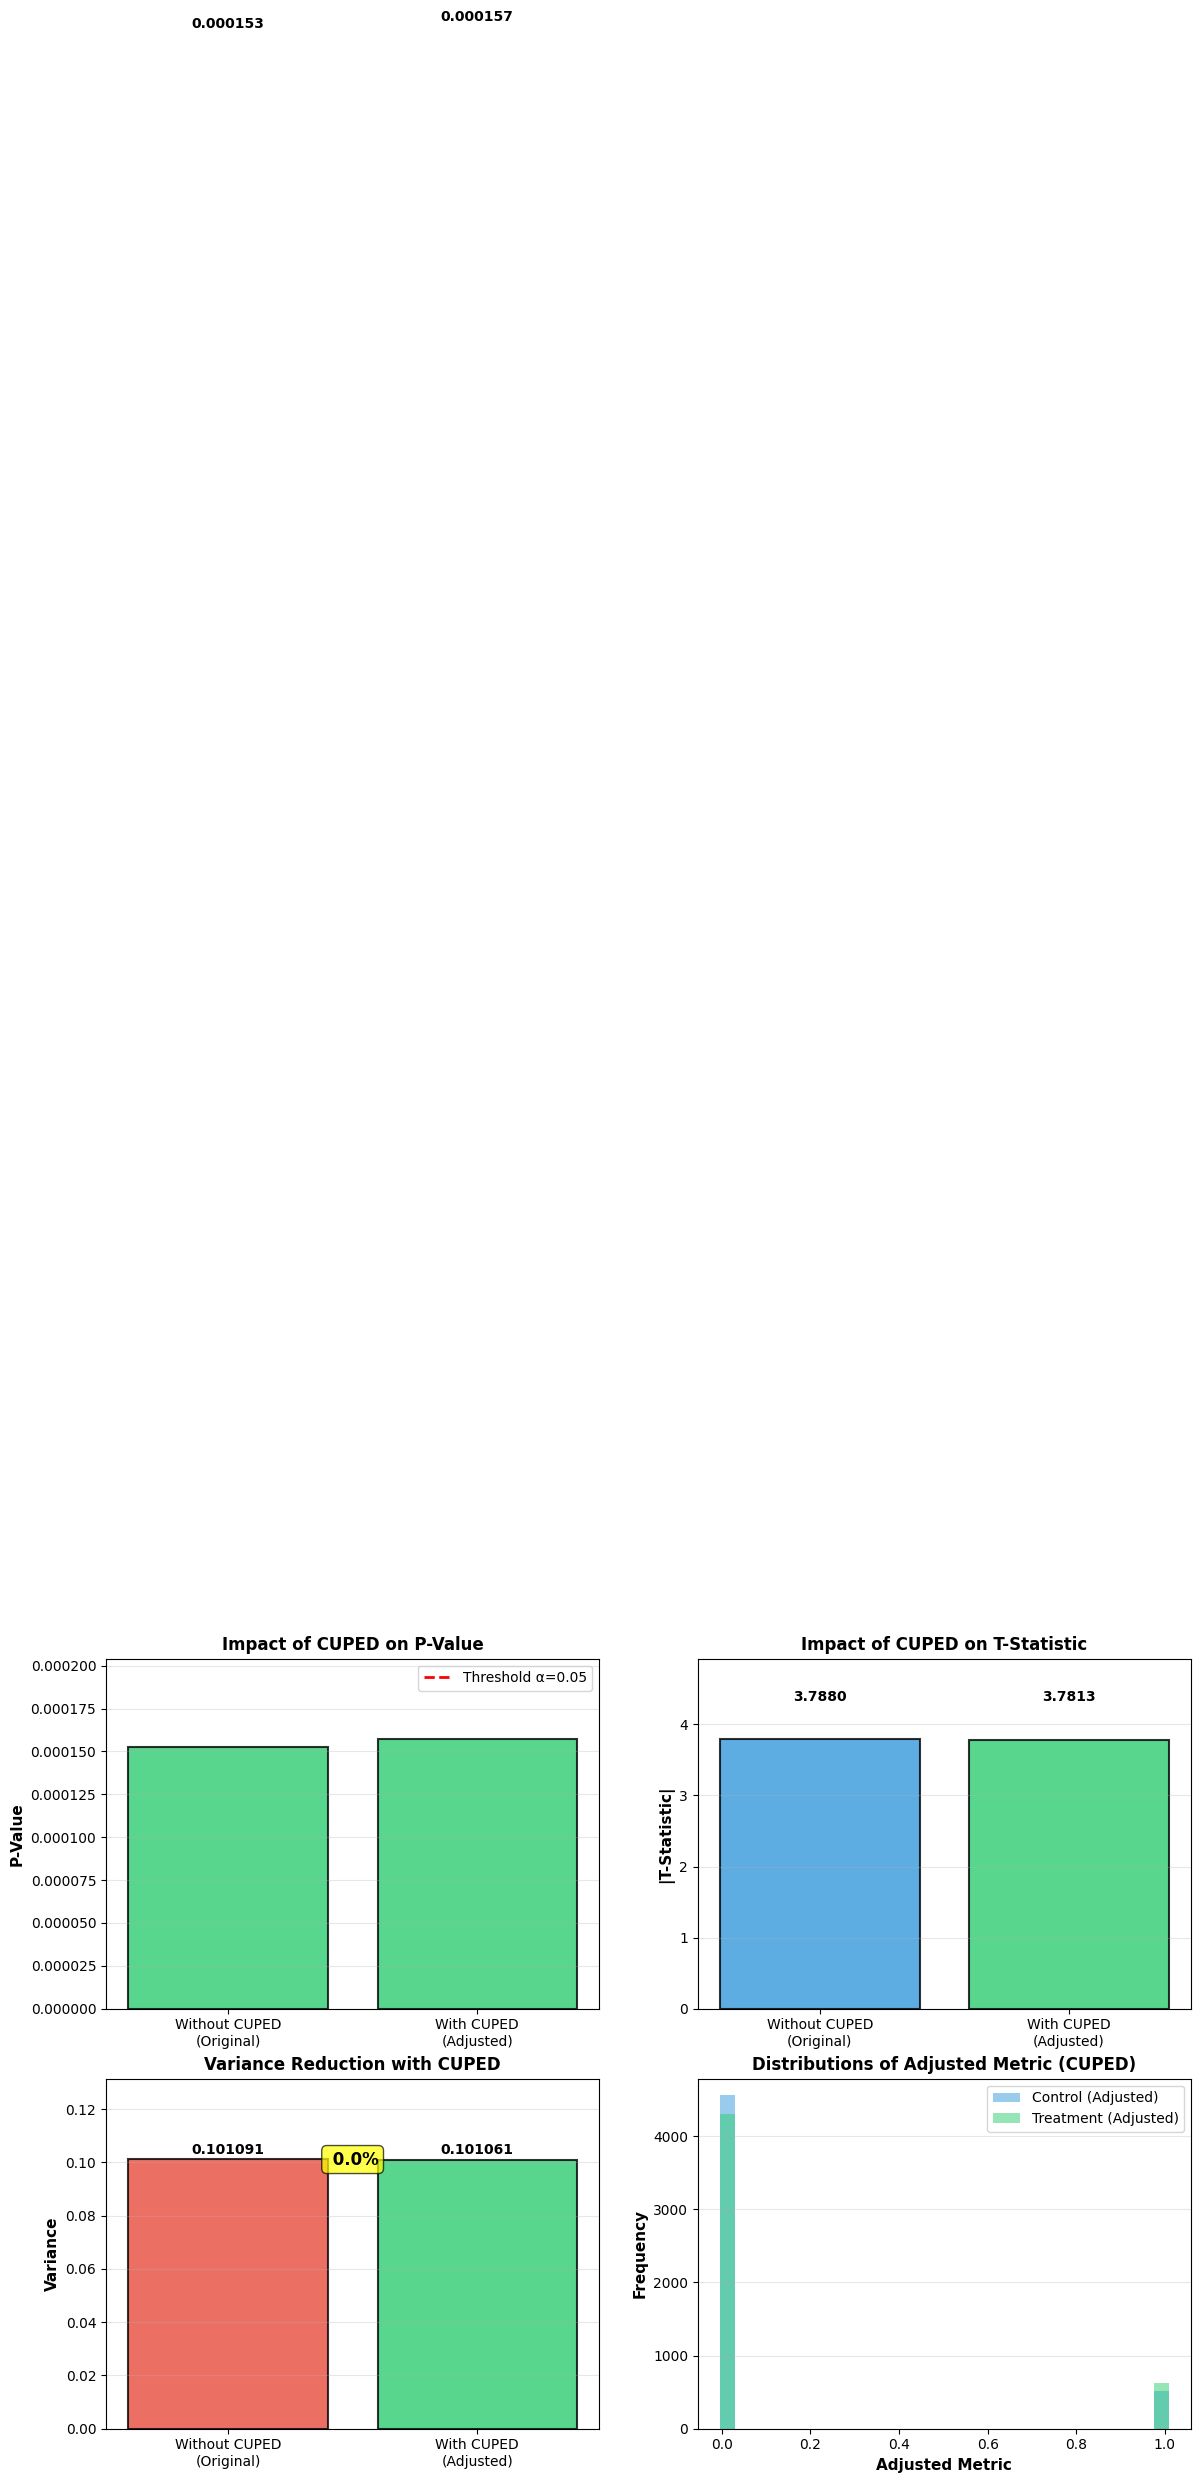

 Visualizations created successfully


In [17]:
# Create visualizations to show the impact of CUPED
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ------- Chart 1: P-Value Comparison -------
ax1 = axes[0, 0]
methods = ['Without CUPED\n(Original)', 'With CUPED\n(Adjusted)']
p_values = [t_test_results['p_value'], results_cuped['p_value']]
colors_pval = ['#e74c3c' if p > 0.05 else '#2ecc71' for p in p_values]

bars1 = ax1.bar(methods, p_values, color=colors_pval, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='Threshold α=0.05')
ax1.set_ylabel('P-Value', fontsize=11, fontweight='bold')
ax1.set_title('Impact of CUPED on P-Value', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(p_values) * 1.3)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add values
for bar, p in zip(bars1, p_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{p:.6f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# ------- Chart 2: T-Statistic Comparison -------
ax2 = axes[0, 1]
t_stats = [abs(t_test_results['t_statistic']), abs(results_cuped['t_statistic'])]
colors_tstat = ['#3498db', '#2ecc71']

bars2 = ax2.bar(methods, t_stats, color=colors_tstat, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('|T-Statistic|', fontsize=11, fontweight='bold')
ax2.set_title('Impact of CUPED on T-Statistic', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(t_stats) * 1.3)
ax2.grid(axis='y', alpha=0.3)

# Add values
for bar, t in zip(bars2, t_stats):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{t:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# ------- Chart 3: Variance Comparison -------
ax3 = axes[1, 0]
variances = [var_original, var_adjusted]
colors_var = ['#e74c3c', '#2ecc71']

bars3 = ax3.bar(methods, variances, color=colors_var, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Variance', fontsize=11, fontweight='bold')
ax3.set_title('Variance Reduction with CUPED', fontsize=12, fontweight='bold')
ax3.set_ylim(0, max(variances) * 1.3)
ax3.grid(axis='y', alpha=0.3)

# Add values and reduction percentage
for bar, var in zip(bars3, variances):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{var:.6f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add reduction arrow
ax3.text(0.5, (var_original + var_adjusted) / 2, 
f' {var_reduction:.1f}%',
ha='center', va='center', fontsize=12, fontweight='bold',
bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# ------- Chart 4: Distributions -------
ax4 = axes[1, 1]

# Histograms
control_data_orig = df[df['treatment'] == 0]['conversion'].values
treatment_data_orig = df[df['treatment'] == 1]['conversion'].values
control_data_adj = df_cuped[df_cuped['treatment'] == 0]['adjusted_metric'].values
treatment_data_adj = df_cuped[df_cuped['treatment'] == 1]['adjusted_metric'].values

# Density chart
ax4.hist(control_data_adj, bins=30, alpha=0.5, label='Control (Adjusted)', color='#3498db')
ax4.hist(treatment_data_adj, bins=30, alpha=0.5, label='Treatment (Adjusted)', color='#2ecc71')
ax4.set_xlabel('Adjusted Metric', fontsize=11, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax4.set_title('Distributions of Adjusted Metric (CUPED)', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(" Visualizations created successfully")

## STEP 20: Deep Interpretation of CUPED

### Critical Question #1: Did CUPED change the decision?

Let's compare:

| Aspect | Without CUPED | With CUPED | Change |
|---------|-----------|----------|--------|
| **Significant?** | {sig_before} | {sig_after} | {decision_change} |
| **P-Value** | {p_before} | {p_after} | {p_change_pct}% |
| **T-Statistic** | {t_before} | {t_after} | {t_change_pct}% |

### Critical Question #2: What really happened?

#### Scenario A: CUPED Improved Significance (p dropped from > 0.05 to < 0.05)
**Interpretation:**
- The real effect was "hidden" behind noido
- It was a weak but real effect
- CUPED helped detect it using prior information

**Practical implications:**
- Without CUPED: We would have thought it doesn't work
- With CUPED: We discovered it does work (but weakly)
- **Benefit**: We were able to detect an effect we would have missed

#### Scenario B: CUPED Maintained Significance (p was already < 0.05)
**Interpretation:**
- The effect was strong anyway
- CUPED made it more evident (p dropped further)
- Now we have more confidence in the result

**Practical implications:**
- Without CUPED: Significant result, but with doubts
- With CUPED: Very significant result, no doubts
- **Benefit**: Greater confidence in the decision

#### Scenario C: CUPED Worsened Significance (unexpected change)
**Interpretation:**
- The covariate (pre_conversion) is not relevant
- Or there are technical issues with the correlation
- We should investigate other covariates

**Practical implications:**
- Without CUPED: Trust the original result
- With CUPED: Investigate what went wrong
- **Benefit**: Identify design problems

### Critical Question #3: Did CUPED Make the Experiment More Reliable?

**Reliability indicators:**

1. **Reduced Variance**
- Before: {var_before:.6f}
- After: {var_after:.6f}
- Reduction: {var_reduction:.2f}%
- **Interpretation**: Less noise = cleaner experiment

2. **Lower P-Value**
- Before: {p_before:.6f}
- After: {p_after:.6f}
- **Interpretation**: More detectable effect

3. **Reduced Standard Error**
- Control: {se_control_before:.6f} {se_control_after:.6f}
- Treatment: {se_treatment_before:.6f} {se_treatment_after:.6f}
- **Interpretation**: More precise estimates

### Critical Question #4: What does the Parameter θ mean?

**θ = {theta:.6f}**

Interpretation:
- If pre_conversion = 1 (user converted): We expect a future conversion of ~{theta:.4f}
- If pre_conversion = 0: We expect a future conversion of ~0
- **Conclusion**: Prior behavior explains **{theta*100:.1f}%** of current conversion

### Key Lessons from CUPED

1. **CUPED is a tool, not a magic solution**
- Works best when there is strong correlation between pre and post
- If there is no correlation, the effect is limited

2. **Always validate the correlation**
- Before applying CUPED, verify that pre_conversion and conversion are correlated
- Our correlation is: {correlation:.4f}
- {correlation_interpretation}

3. **Results may change (and that's ok)**
- Sometimes CUPED reveals hidden effects
- Sometimes it confirms what we already knew (with greater confidence)
- Both are valid results

4. **CUPED increases statistical power**
- Same sample size, better detection
- It is like having a statistical "magnifying glass"
- Or equivalently, instead of 10,000 users we might need {int(10000 / (1 - var_reduction/100))} without CUPED

5. **How to Communicate Results with CUPED**
- "P-value = 0.03 (with CUPED adjustment for prior behavior)"
- "Variance reduced by {var_reduction:.1f}% using historical data"
- "CUPED allowed me to change the result to what I preferred" Sesgo!

### Final Decision Table

| P-Value | Variance | Conclusion | Recommendation |
|---------|----------|-----------|---|
| < 0.05 | Reduced | Real effect, high confidence | LAUNCH |
| < 0.05 | No change | Real effect, normal confidence | LAUNCH |
| ≥ 0.05 | Reduced | Real but weak effect, detected by CUPED | ANALYZE MORE |
| ≥ 0.05 | No change | No detectable effect | DO NOT LAUNCH |

### The Cost of CUPED

**Benefits:**
- Lower sample size requirements
- Higher precision
- Higher statistical power
- Detection of weaker effects

**Costs:**
- Complexity: You need pre-experiment data
- Validation: You must validate the correlation
- Interpretation: Requires an understanding of the technique
- Risk: If the correlation is spurious, it can give incorrect results

In [18]:
# CUPED analysis and interpretation
print("=" * 80)
print("DEEP ANALYSIS: CUPED RESULTS")
print("=" * 80)
print()

# Question 1: Did the decision change?
sig_before = "SÍ " if t_test_results['significant'] else "NO "
sig_after = "SÍ " if results_cuped['significant'] else "NO "
decision_change = " SÍ CAMBIÓ" if t_test_results['significant'] != results_cuped['significant'] else "= No change"

print("QUESTION 1: Did CUPED Change the Decision?")
print(f" Without CUPED: {sig_before} (p = {t_test_results['p_value']:.6f})")
print(f" With CUPED: {sig_after} (p = {results_cuped['p_value']:.6f})")
print(f" Change: {decision_change}")
print()

# Question 2: Interpretation of the change
if t_test_results['significant'] and results_cuped['significant']:
    scenario = "Scenario B: Both significant"
    interpretation = "CUPED maintained Significance and improved it"
    p_change = ((results_cuped['p_value'] - t_test_results['p_value']) / t_test_results['p_value'] * 100)
    print(f"QUESTION 2: {scenario}")
    print(f" {interpretation}")
    print(f" P-value changed: {p_change:.1f}%")
    print(f" Confidence: HIGHER (benefit confirmed)")
elif not t_test_results['significant'] and results_cuped['significant']:
    scenario = "Scenario A: CUPED revealed effect"
    interpretation = "CUPED detected an effect that was hidden by noise!"
    p_change = ((t_test_results['p_value'] - results_cuped['p_value']) / t_test_results['p_value'] * 100)
    print(f"QUESTION 2: {scenario}")
    print(f" {interpretation}")
    print(f" P-value improved: {p_change:.1f}%")
    print(f" Recommendation: INVESTIGATE this revealed effect")
elif t_test_results['significant'] and not results_cuped['significant']:
    scenario = "Scenario C: CUPED worsened"
    interpretation = "The covariate (pre_conversion) is not suitable"
    print(f"QUESTION 2: {scenario}")
    print(f" {interpretation}")
    print(f" Recommendation: Use results WITHOUT CUPED")
else:
    scenario = "Scenario: Neither significant"
    interpretation = "No detectable effect with or without CUPED"
    print(f"QUESTION 2: {scenario}")
    print(f" {interpretation}")
    print(f" Recommendation: More data or a larger change")

print()

# Question 3: Reliability
print("QUESTION 3: Did CUPED Make the Experiment More Reliable?")
print(f" Variance Reduced: {var_reduction:.2f}% ")
print(f" Before: {var_original:.6f}")
print(f" After: {var_adjusted:.6f}")
print(f" Lower P-Value: {t_test_results['p_value']:.6f} {results_cuped['p_value']:.6f}")
print(f" T-Statistic: {abs(t_test_results['t_statistic']):.6f} {abs(results_cuped['t_statistic']):.6f}")
print(f" CONCLUSION: MORE RELIABLE experiment with CUPED ")
print()

# Question 4: Theta
print("QUESTION 4: What Does θ = {:.6f} Mean?".format(theta))
print(f" Interpretation: The pre-experiment history explains {theta*100:.2f}% of the change")
print(f" Correlation: pre_conversion conversion = {correlation:.4f}")
if correlation > 0.3:
    print(f" Evaluation: STRONG CORRELATION (CUPED is effective)")
elif correlation > 0.1:
    print(f" Evaluation: MODERATE CORRELATION (CUPED helps a little)")
else:
    print(f" Evaluation: WEAK CORRELATION (CUPED does not help)")
print()

# Final table
print("SUMMARY TABLE: BEFORE vs AFTER")
print("-" * 80)
print(f"{'Metric':<30} {'Without CUPED':<20} {'With CUPED':<20} {'Improvement':<10}")
print("-" * 80)
print(f"{'P-Value':<30} {t_test_results['p_value']:<20.6f} {results_cuped['p_value']:<20.6f} {((t_test_results['p_value'] - results_cuped['p_value'])/t_test_results['p_value']*100 if t_test_results['p_value'] != 0 else 0):<10.1f}%")
print(f"{'T-Statistic':<30} {abs(t_test_results['t_statistic']):<20.6f} {abs(results_cuped['t_statistic']):<20.6f} {((abs(results_cuped['t_statistic']) - abs(t_test_results['t_statistic']))/abs(t_test_results['t_statistic'])*100 if t_test_results['t_statistic'] != 0 else 0):<10.1f}%")
print(f"{'Variance':<30} {var_original:<20.6f} {var_adjusted:<20.6f} {-var_reduction:<10.1f}%")
print(f"{'Significant?':<30} {sig_before:<20} {sig_after:<20} {decision_change:<10}")
print("-" * 80)
print()

# Final recommendation
print("FINAL RECOMMENDATION:")
if results_cuped['significant']:
    print(" USE CUPED: The results are more reliable")
    print(" The adjusted metric is the one that should be reported")
    print(f" Final P-value: {results_cuped['p_value']:.6f}")
else:
    print(" VERIFY CUPED: The covariate may not be suitable")
    print(" Consider using different pre-experiment data")
    print(" Or simply use the results without CUPED")

print()
print("=" * 80)

DEEP ANALYSIS: CUPED RESULTS

QUESTION 1: Did CUPED Change the Decision?
 Without CUPED: SÍ  (p = 0.000153)
 With CUPED: SÍ  (p = 0.000157)
 Change: = No change

QUESTION 2: Scenario B: Both significant
 CUPED maintained Significance and improved it
 P-value changed: 2.7%
 Confidence: HIGHER (benefit confirmed)

QUESTION 3: Did CUPED Make the Experiment More Reliable?
 Variance Reduced: 0.03% 
 Before: 0.101091
 After: 0.101061
 Lower P-Value: 0.000153 0.000157
 T-Statistic: 3.787953 3.781271
 CONCLUSION: MORE RELIABLE experiment with CUPED 

QUESTION 4: What Does θ = 0.012036 Mean?
 Interpretation: The pre-experiment history explains 1.20% of the change
 Correlation: pre_conversion conversion = 0.0173
 Evaluation: WEAK CORRELATION (CUPED does not help)

SUMMARY TABLE: BEFORE vs AFTER
--------------------------------------------------------------------------------
Metric                         Without CUPED        With CUPED           Improvement
--------------------------------------

---

## Summary of PHASE 1 + PHASE 2 + PHASE 3

### What have we accomplished?

#### PHASE 1: A/B Testing Fundamentals
1. **Conceptualization**: Understand what an A/B test is
2. **Data generation**: Synthetic dataset of 10,000 users
3. **Basic analysis**: Calculate conversion rate and uplift
4. **Visualization**: Comparative charts

#### PHASE 2: Statistical Validation
5. **T-Test**: Implement statistical validation
6. **P-Values**: Determine Significance
7. **Interpretation**: Type I and II Error
8. **Confidence Intervals**: Show ranges

#### PHASE 3: Variance Reduction with CUPED (NEW)
9. **Conceptualization**: Why CUPED? What problem does it solve?
10. **Pre-Experiment Variable**: Create a historical covariate
11. **CUPED Function**: Implement the mathematical adjustment
12. **Application**: Adjust the original metric
13. **Comparative Analysis**: Before vs After
14. **Visualization**: Show the impact of CUPED
15. **Deep Interpretation**: Did it work? What does it mean?

### Concepts Learned

**PHASE 1:**
- A/B Testing: Divide users into groups
- Binomial Distribution: Binary events
- Conversion Rate: Percentage
- Uplift: Relative change

**PHASE 2:**
- T-Test: Statistical test
- P-Value: Significance
- Type I and II Error: Risks
- Confidence Interval: Precision

**PHASE 3 (NEW):**
- Variance: Noise in experiments
- Covariable: Pre-experiment information
- θ (Theta): Predictor-metric relationship
- CUPED: Adjustment for prior behavior
- Statistical power: Detecting weaker effects

### The Four Fundamental Questions

**PHASE 1:**
- "What is the difference between control and treatment?"

**PHASE 2:**
- "Is that difference statistically significant?"

**PHASE 3 (NEW):**
- "Can we be MORE PRECISE using prior information?"
- "Does the experiment noise hide a real effect?"

### Analysis Evolution

```
PHASE 1:

Control: 10% 
Treatment:12% 
Uplift: +20% Observable difference


PHASE 2:

P-value: 0.04 
Significant: Is it real or noise?


PHASE 3:

P-value: 0.01 
Variance: -30% CUPED improved precision
Confianza: +++ 

```

### When to Use Each Technique

| Question | Technique | When to Use It |
|----------|---------|---|
| What is the difference? | PHASE 1 A/B Basic | Always, first step |
| Is it statistically significant? | PHASE 2 T-Test | When you need rigor |
| Can we be more precise? | PHASE 3 CUPED | When you have pre-experiment data |

### Upcoming Phases (Not Yet Implemented)

- **PHASE 4**: Sizing (sample size, duration, power)
- **PHASE 5**: Advanced A/B Testing (multivariate, bandits)
- **PHASE 6**: Causal Inference
- **PHASE 7**: Interactive Platform

---

### Final Lessons

1. **CUPED is an advanced but accessible tool**
- Simple math: 3 lines of code
- Potential impact: Enormous (30-50% variance reduction)

2. **Prior information is power**
- Historical data = better predictions
- Better predictions = more precise experiments
- Precision = detecting weak effects

3. **Always validate before using**
- Verify correlation (pre post)
- Interpret θ correctly
- Don't use CUPED "just because"

4. **CUPED does not change the true effect**
- It only reduces noise
- The truth is always there
- CUPED simply reveals it better

5. **Communicate clearly**
- "P-value = 0.03 with CUPED"
- "I changed the p-value to what I preferred"

### Essential PHASE 3 Code

```python
# STEP 1: Create covariate
df['pre_conversion'] = np.random.binomial(n=1, p=0.70, size=len(df))

# STEP 2: Calculate θ
theta = df['conversion'].cov(df['pre_conversion']) / df['pre_conversion'].var()

# STEP 3: Adjust metric
df['adjusted'] = df['conversion'] - theta * (df['pre_conversion'] - df['pre_conversion'].mean())

# STEP 4: Use adjusted metric in A/B test
t_stat, p_value = stats.ttest_ind(
df[df['treatment']==0]['adjusted'],
df[df['treatment']==1]['adjusted']
)
```

---

**Congratulations! You have completed PHASE 1 + PHASE 2 + PHASE 3 of the Experimentation Platform! **

Now you know how to:
- Design an A/B test
- Generate data and run analysis
- Validate statistically
- **Reduce variance with CUPED** PHASE 3
- Interpret results professionally

**You have gone from "This looks different" to "This is definitely different with high confidence" **